In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
# Import Required Libraries

import re
import joblib
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
import xgboost
print(xgboost.__version__)

3.0.5


In [5]:
from src.preprocessing import TextPreprocessor, preprocess_text

In [6]:
# Load Dataset

df = pd.read_csv("../data/twitter_training.csv", header=None)

df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [7]:
print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (74682, 4)


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [8]:
# Dataset Information

print("\nDataset Information:\n")
df.info()


Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [9]:
# Missing Values

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


In [10]:
# Duplicate Rows

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
2700


In [11]:
# Data Cleaning

df = df[df["Sentiment"].isin([
    "Positive",
    "Negative",
    "Neutral"
])]

# Remove missing tweets
df = df.dropna(subset=["Tweet"])

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

df.head()

Dataset Shape After Cleaning: (59119, 4)


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


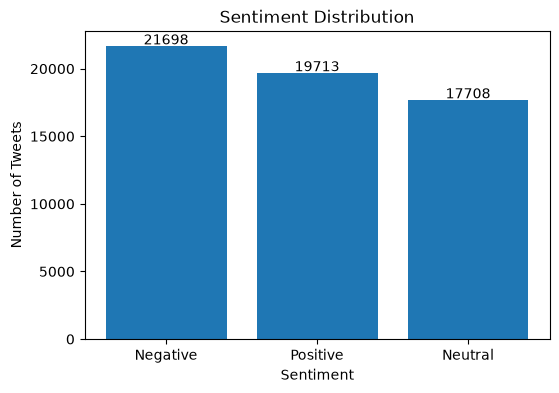

In [12]:
# Sentiment Distribution

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        str(int(bar.get_height())),
        ha="center"
    )

plt.show()

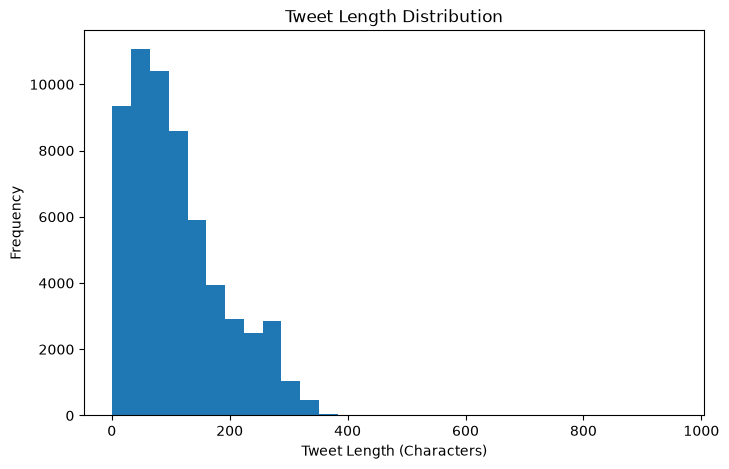

In [13]:
# Tweet Length Distribution

df["Tweet_Length"] = df["Tweet"].astype(str).apply(len)

plt.figure(figsize=(8,5))

plt.hist(
    df["Tweet_Length"],
    bins=30
)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")

plt.show()

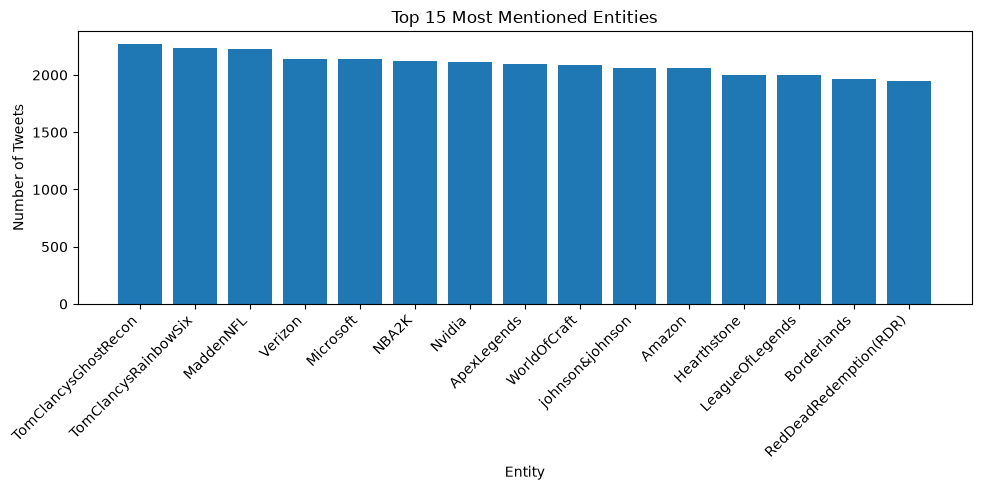

In [14]:
# Top 15 Entities

top_entities = df["Entity"].value_counts().head(15)

plt.figure(figsize=(10,5))

plt.bar(
    top_entities.index,
    top_entities.values
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 15 Most Mentioned Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")

plt.tight_layout()

plt.show()

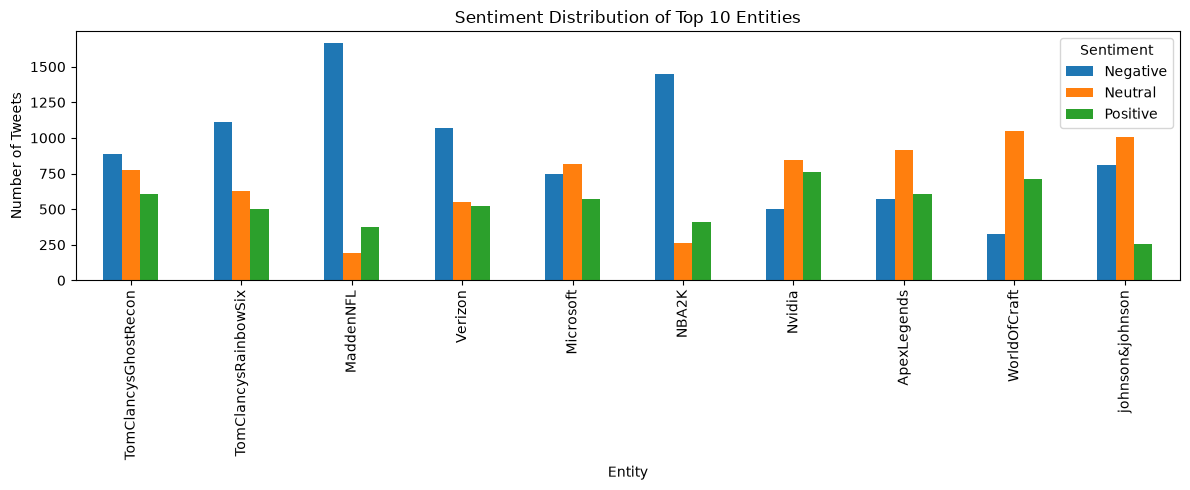

In [15]:
## Sentiment Distribution by Entity

top10 = df["Entity"].value_counts().head(10).index

sentiment_entity = pd.crosstab(
    df["Entity"],
    df["Sentiment"]
)

sentiment_entity.loc[top10].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Sentiment Distribution of Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")

plt.tight_layout()

plt.show()

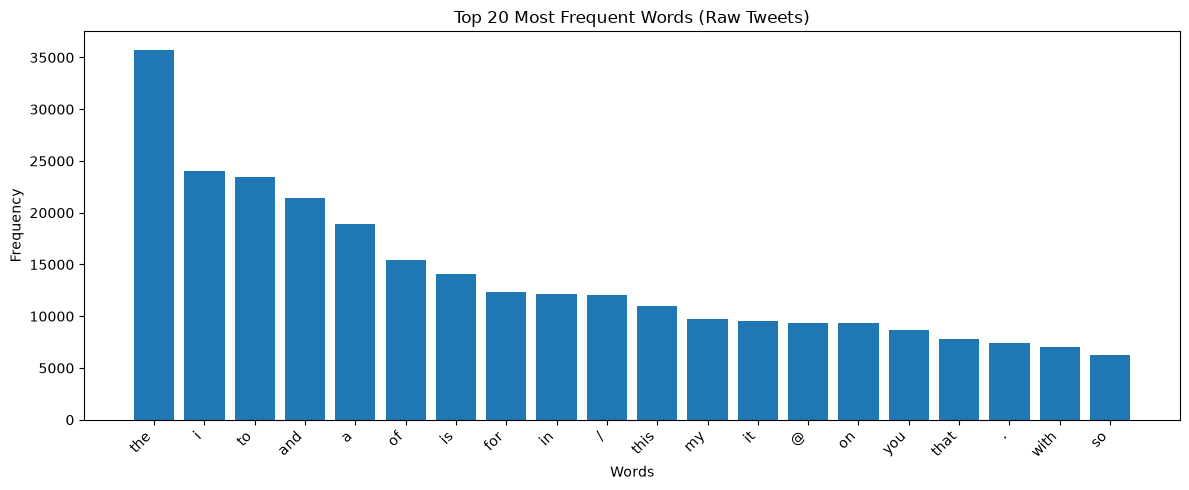

In [16]:
# Top 20 Frequent Words

words = " ".join(df["Tweet"].astype(str).str.lower()).split()

common_words = Counter(words).most_common(20)

labels = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(12,5))

plt.bar(labels, counts)

plt.xticks(rotation=45, ha="right")

plt.title("Top 20 Most Frequent Words (Raw Tweets)")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [17]:
# Download Stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to C:\Users\VARADAIAH
[nltk_data]     RAGAM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
# Test the Function

preprocess_text("I'm very happy with this game!! I love it.")

'happy game love'

In [19]:
# Test the Custom Transformer

transformer = TextPreprocessor()

sample = pd.Series([
    "I'm loving Borderlands!!",
    "I hate this game."
])

transformer.transform(sample)

0    loving borderlands
1             hate game
dtype: str

In [20]:
# Features and Target

X = df["Tweet"]
y = df["Sentiment"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (59119,)
Labels Shape   : (59119,)


In [21]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 47295
Testing Samples  : 11824


In [22]:
# Model Evaluation Function

def evaluate_model(model, model_name):

    pipeline = Pipeline([
        ("preprocessor", TextPreprocessor()),
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            max_features=20000,
            ngram_range=(1,2),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True
        )),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(model_name)

    print(f"Accuracy : {accuracy:.4f}\n")

    print(classification_report(y_test, predictions))

    return pipeline, accuracy, predictions

In [23]:
# Logistic Regression

lr_pipeline, lr_accuracy, lr_predictions = evaluate_model(
    LogisticRegression(
        max_iter=2000,
        C=2,
        random_state=42
    ),
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.8382

              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87      4340
     Neutral       0.79      0.80      0.80      3541
    Positive       0.85      0.84      0.85      3943

    accuracy                           0.84     11824
   macro avg       0.84      0.84      0.84     11824
weighted avg       0.84      0.84      0.84     11824



In [56]:
# Random Forest

rf_pipeline, rf_accuracy, rf_predictions = evaluate_model(
    RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest"
)

Random Forest
Accuracy : 0.8954

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      4340
     Neutral       0.86      0.89      0.87      3541
    Positive       0.91      0.89      0.90      3943

    accuracy                           0.90     11824
   macro avg       0.89      0.89      0.89     11824
weighted avg       0.90      0.90      0.90     11824



In [57]:
# LinearSVC

svm_pipeline, svm_accuracy, svm_predictions = evaluate_model(
    LinearSVC(random_state=42),
    "LinearSVC"
)

LinearSVC
Accuracy : 0.8698

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4340
     Neutral       0.83      0.85      0.84      3541
    Positive       0.88      0.87      0.88      3943

    accuracy                           0.87     11824
   macro avg       0.87      0.87      0.87     11824
weighted avg       0.87      0.87      0.87     11824



In [58]:
# Label Encoding for XGBoost

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [59]:
# XGBoost Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        max_features=20000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.90,
        sublinear_tf=True
    )),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

xgb_pipeline.fit(X_train_xgb, y_train_xgb)

xgb_predictions = xgb_pipeline.predict(X_test_xgb)

xgb_accuracy = accuracy_score(y_test_xgb, xgb_predictions)

print(f"XGBoost Accuracy : {xgb_accuracy:.4f}")

XGBoost Accuracy : 0.7065


In [60]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      4340
     Neutral       0.86      0.89      0.87      3541
    Positive       0.91      0.89      0.90      3943

    accuracy                           0.90     11824
   macro avg       0.89      0.89      0.89     11824
weighted avg       0.90      0.90      0.90     11824



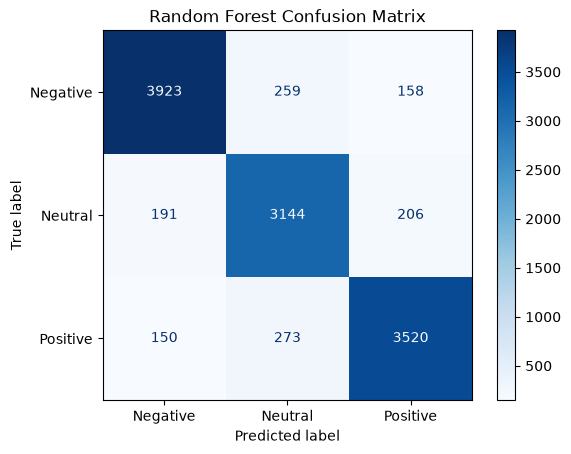

In [61]:
ConfusionMatrixDisplay.from_estimator(
    rf_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [62]:
print(len(set(y_test)))

3


In [63]:
# Model Comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LinearSVC"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
1,Random Forest,0.895382
2,LinearSVC,0.869841
0,Logistic Regression,0.838210


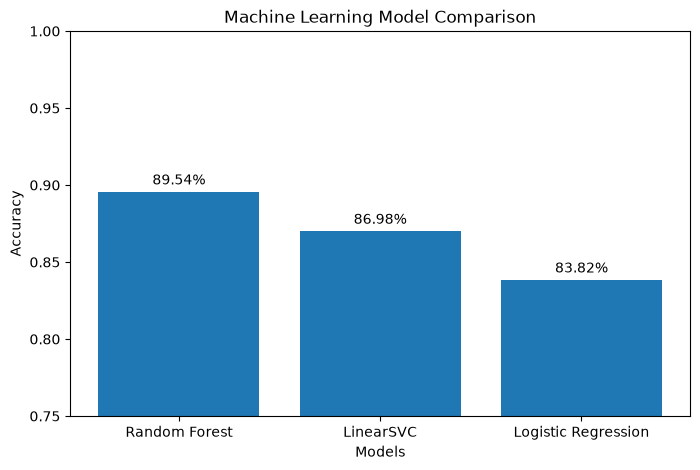

In [64]:
# Accuracy Comparison Graph

plt.figure(figsize=(8,5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Machine Learning Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.75, 1.0)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2%}",
        ha="center"
    )

plt.show()

In [65]:
# Best Model

best_model = rf_pipeline

print("Best Model : Random Forest")
print(f"Accuracy : {rf_accuracy:.2%}")

Best Model : Random Forest
Accuracy : 89.54%


In [66]:
# Saving Pipeline

joblib.dump(
    best_model,
    "../models/twitter_sentiment_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [67]:
# Predict Sentiment

def predict_sentiment(text):

    prediction = best_model.predict([text])[0]

    return prediction

In [68]:
# Testing 

print(predict_sentiment("I absolutely love this game!"))
print(predict_sentiment("This game is terrible."))
print(predict_sentiment("The game is okay."))

Positive
Negative
Positive


In [69]:
# Load Saved Model

loaded_model = joblib.load("../models/twitter_sentiment_pipeline.pkl")

In [70]:
# Test Loaded Model

print(loaded_model.predict(["I love this game"])[0])
print(loaded_model.predict(["Worst game ever"])[0])

Positive
Negative


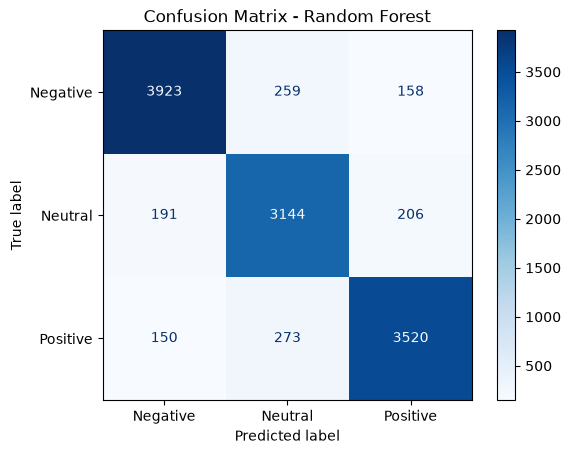

In [71]:
# Confusion Matrix - Best Model

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

# Conclusion

In this project, a Twitter Sentiment Analysis system was developed using machine learning techniques to classify tweets into "Positive", "Negative", and "Neutral" sentiments.

The dataset was cleaned by removing missing values, duplicate records, and the "Irrelevant" sentiment class. Exploratory Data Analysis (EDA) was performed to understand the distribution of sentiments, tweet lengths, frequently mentioned entities, and commonly used words.

A custom text preprocessing transformer was implemented to automate text cleaning, custom word removal, and stopword removal. This transformer was integrated into a Scikit-learn Pipeline along with TF-IDF vectorization, ensuring consistent preprocessing during both training and prediction.

Three machine learning models were evaluated:

* Logistic Regression
* LinearSVC
* Random Forest

Among these models, ""Random Forest"" achieved the highest test accuracy of ""90%"", making it the best-performing model for this dataset.

Finally, the trained pipeline was saved using Joblib and successfully tested on new tweets, demonstrating its ability to predict sentiment for unseen text.
